ADOPCION DE VEHICULOS ELECTRICOS Y CLASIFICACION DE LA ANSIEDAD POR LA UTONOMIA

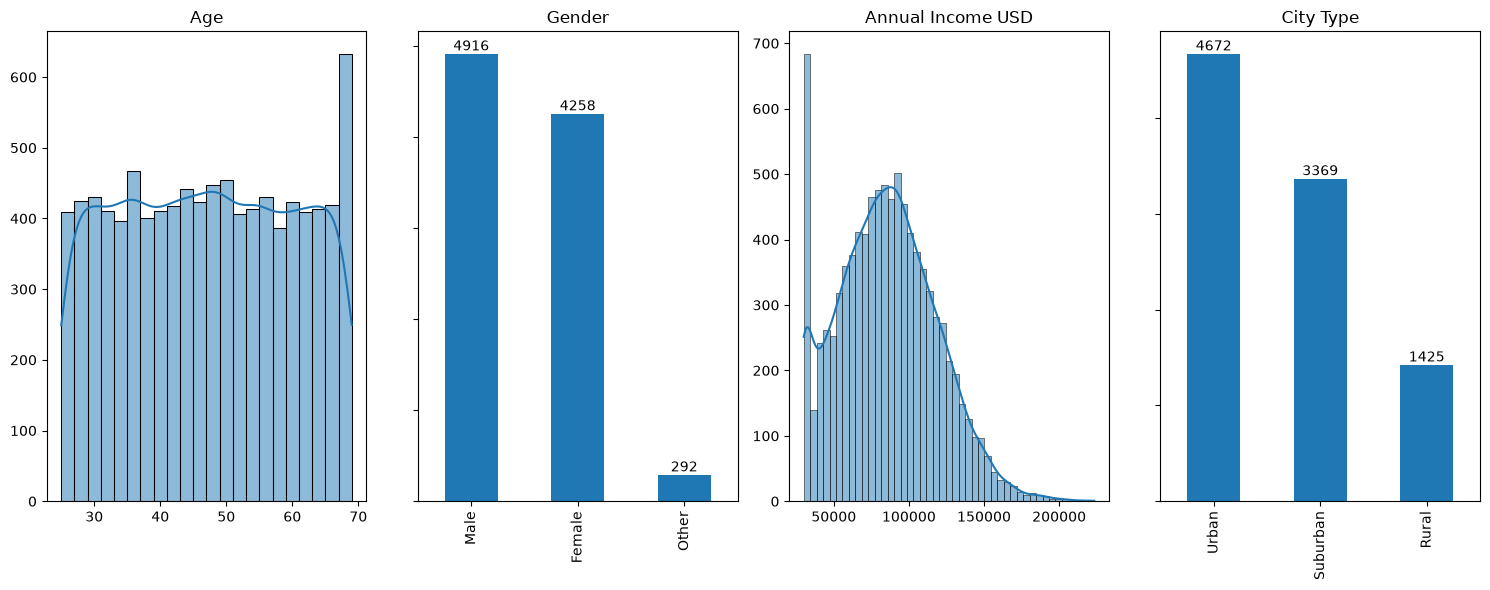

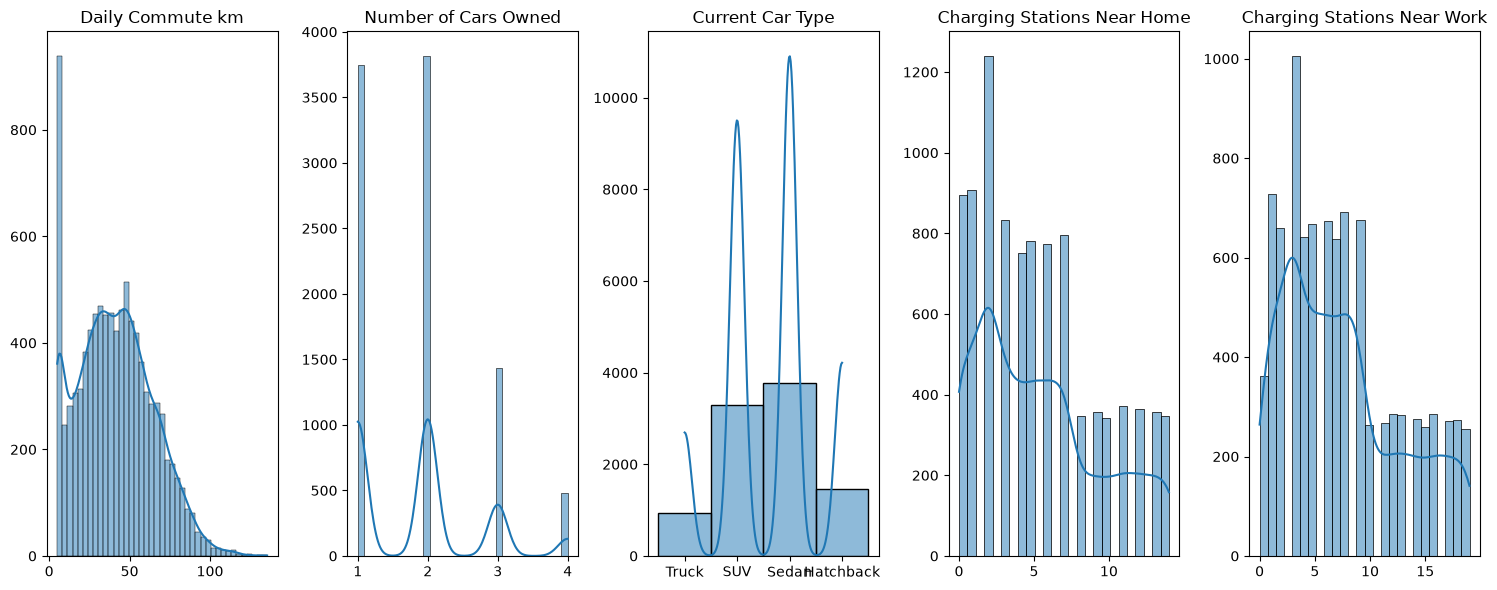

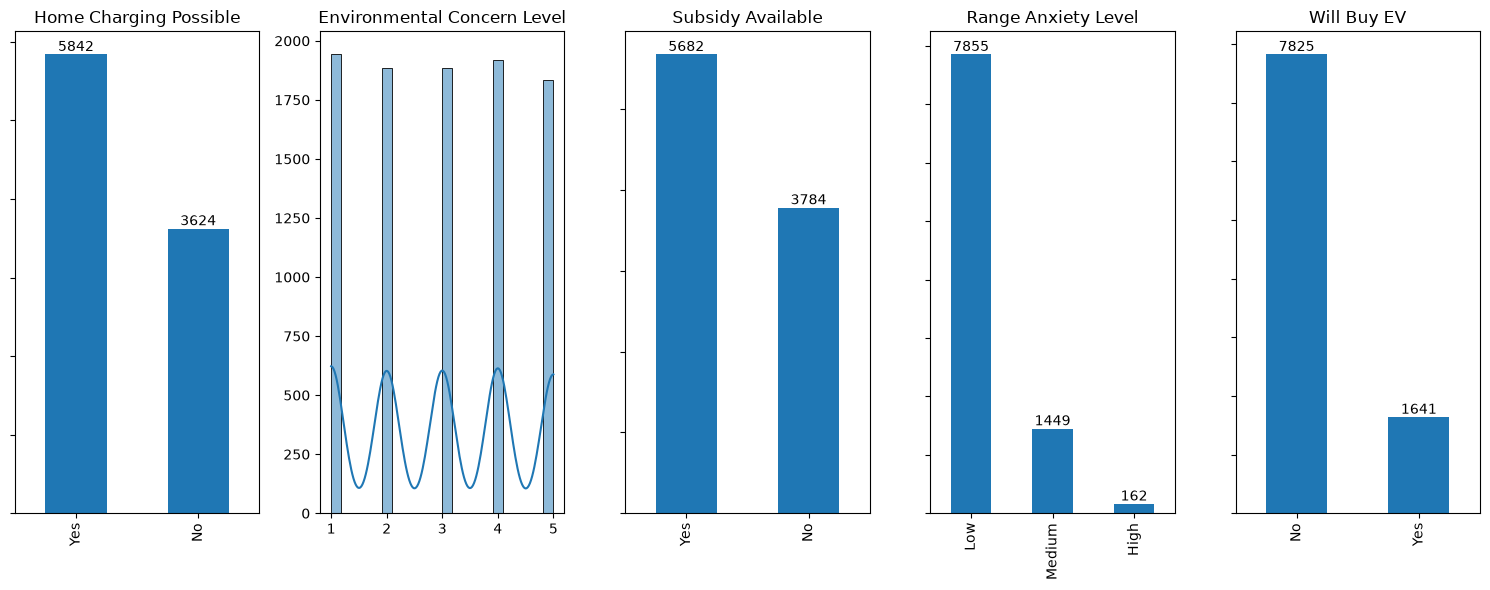

In [ ]:
import numpy as np # Operaciones numéricas y álgebra lineal
import pandas as pd # Manipulación y análisis de datos tabular (DataFrames)

# Ignorar advertencias no críticas durante la ejecución
import warnings
warnings.filterwarnings("ignore")

# Preprocesamiento y división de datos
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Modelos de Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Métricas de evaluación de modelos
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Manejo de desbalance de clases mediante pesos de muestras
from sklearn.utils.class_weight import compute_sample_weight

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, HTML

def bar_labels(axes, rotation=0, location="edge"):
    for container in axes.containers:
        axes.bar_label(container, label_type=location, rotation=rotation)
    axes.set_xlabel("")
    axes.set_ylabel("")
    axes.set_yticklabels(())

def training_classification():
    # Inicialización de los algoritmos de clasificación
    rfc = RandomForestClassifier()
    abc = AdaBoostClassifier()
    gbc = GradientBoostingClassifier()
    etc = ExtraTreesClassifier()
    lgr = LogisticRegression()
    svc = SVC()
    xgb = XGBClassifier()
    lgb = LGBMClassifier(verbose=-100)
    cat = CatBoostClassifier(verbose=False)

    # Lista de instancias y nombres para mapear resultados
    models = [rfc, abc, gbc, etc, lgr,
             svc, xgb, lgb, cat]

    names = ["Random Forest", "Ada Boost", "Gradient Boosting", "Extra Trees", "Logistic Regression",
            "SVC", "XGBoost", "LightGBM", "Cat Boost"]

    scores = []
    cms = dict()
    reports = dict()

    # Cálculo de pesos para balancear la importancia de las clases en el entrenamiento
    sample_weights = compute_sample_weight(
        class_weight='balanced',
        y=y_train # Requiere que y_train esté definido previamente en el entorno
    )

    # Entrenamiento y evaluación iterativa de cada modelo
    for i, j in enumerate(names):
        models[i].fit(x_train, y_train, sample_weight=sample_weights)# Entrenamiento con pesos
        pred = models[i].predict(x_test)# Predicción con conjunto de prueba
        # Almacenamiento de métricas por modelo
        scores += [accuracy_score(pred, y_test)]
        cms[j] = confusion_matrix(pred, y_test)
        reports[j] = classification_report(pred, y_test)

    # Creación y ordenamiento del DataFrame con los resultados de Accuracy
    dt = pd.DataFrame({"scores": scores}, index=names)
    dt = dt.sort_values("scores", ascending=False)

    dt["scores"] = dt["scores"]*100
    dt["scores"] = round(dt["scores"], 2)

    fig, axes = plt.subplots(figsize=(15, 6))

    dt["scores"].plot(kind="bar", ax=axes)
    bar_labels(axes)

    index = 0

    for _ in range(3):
        fig, axes = plt.subplots(ncols=3, figsize=(15, 6))
        for i in range(3):
            sns.heatmap(cms[dt.index[index]], annot=True, ax=axes[i])
            axes[i].set_title("{}: {}%".format(dt.index[index], dt.iloc[index, 0]))
            index += 1
        plt.tight_layout()
        plt.show()

    for i in dt.index:
        print("*"*30)
        print("\n")
        print(i)
        print("\n")
        print(reports[i])

df = pd.read_csv("EV_Adoption_and_Range_Anxiety_Dataset.csv")

df = df.iloc[:, 1:]

df.dropna(inplace=True)

cats = [i for i in df.columns if df[i].dtype == 'O' or df[i].nunique() <= 3]
nums = [i for i in df.columns if i not in cats]

index = 0

for _ in [4, 5, 5]:
    fig, axes = plt.subplots(ncols=_, figsize=(15, 6))
    for i in range(_):
        if df.columns[index] in cats:
            df[df.columns[index]].value_counts()[:10].plot(kind="bar", ax=axes[i])
            bar_labels(axes[i])
        else:
            sns.histplot(df, x=df.columns[index], kde=True, ax=axes[i])
            axes[i].set_xlabel("")
            axes[i].set_ylabel("")
        axes[i].set_title(df.columns[index].replace('_', ' '))

        index += 1
    plt.tight_layout()
    plt.show()

VEHICULOS ELECTRICOS COMPRADOS: CARACTERISTICAS COMUNES

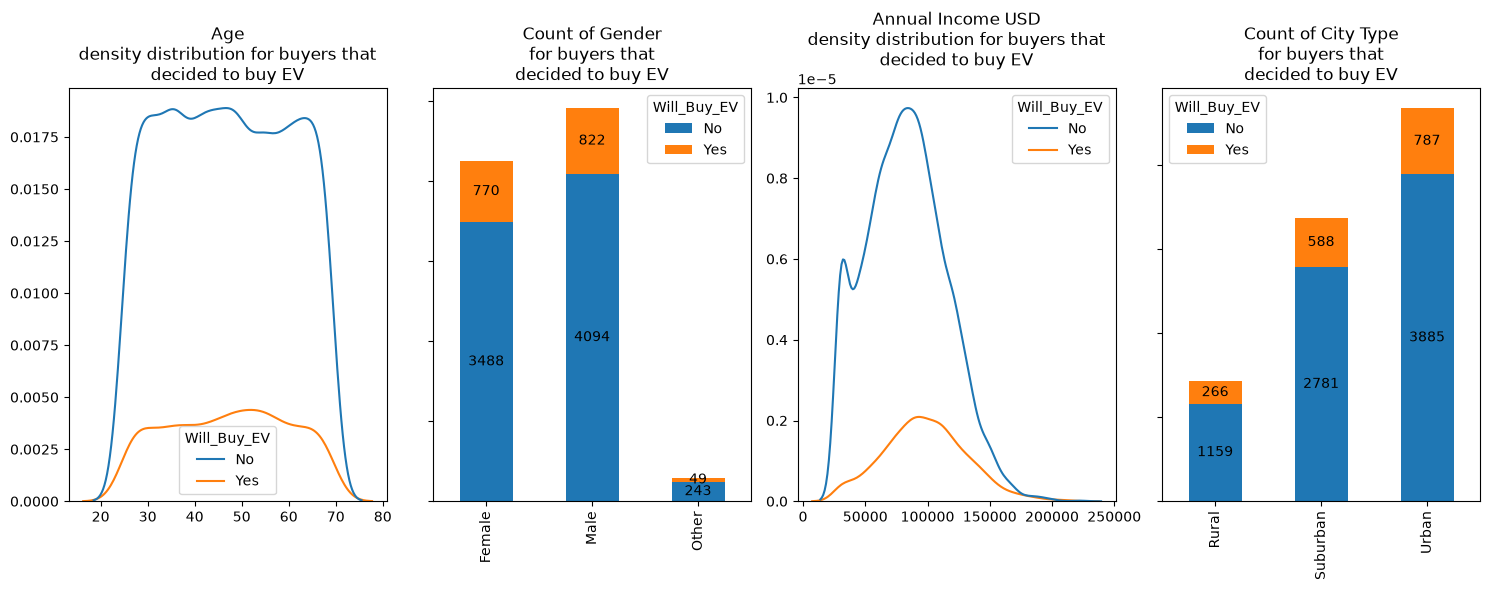

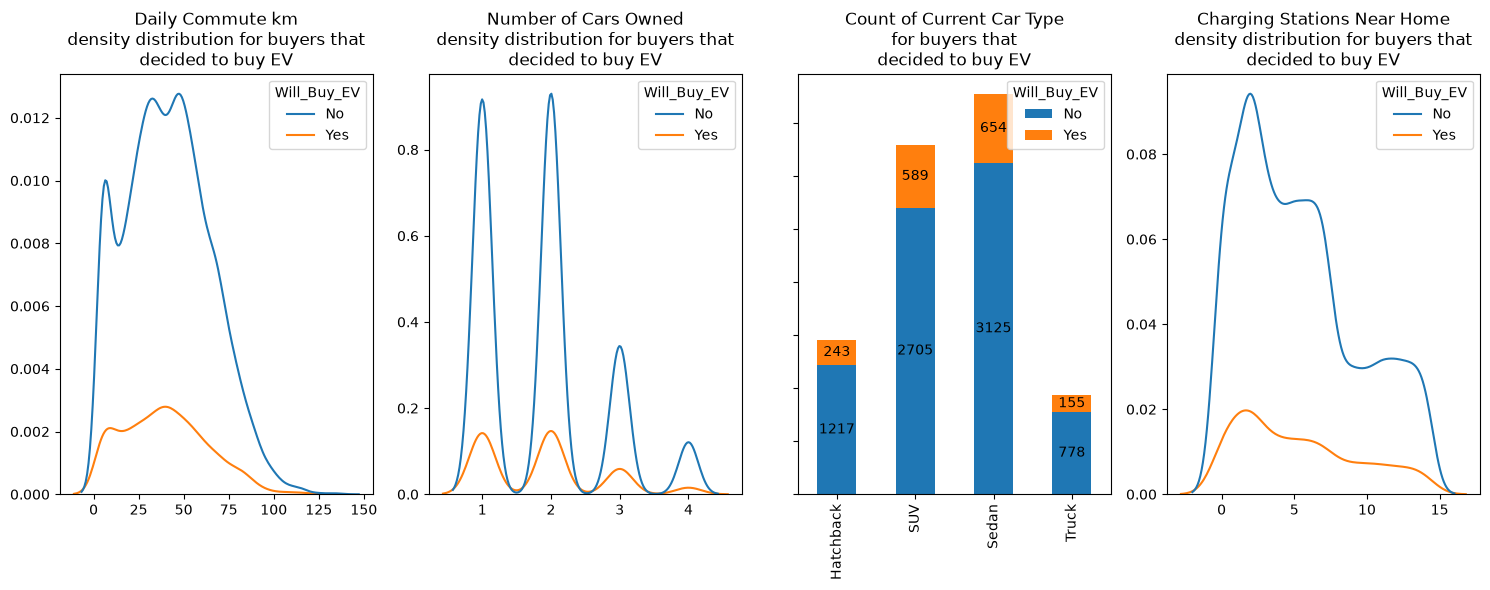

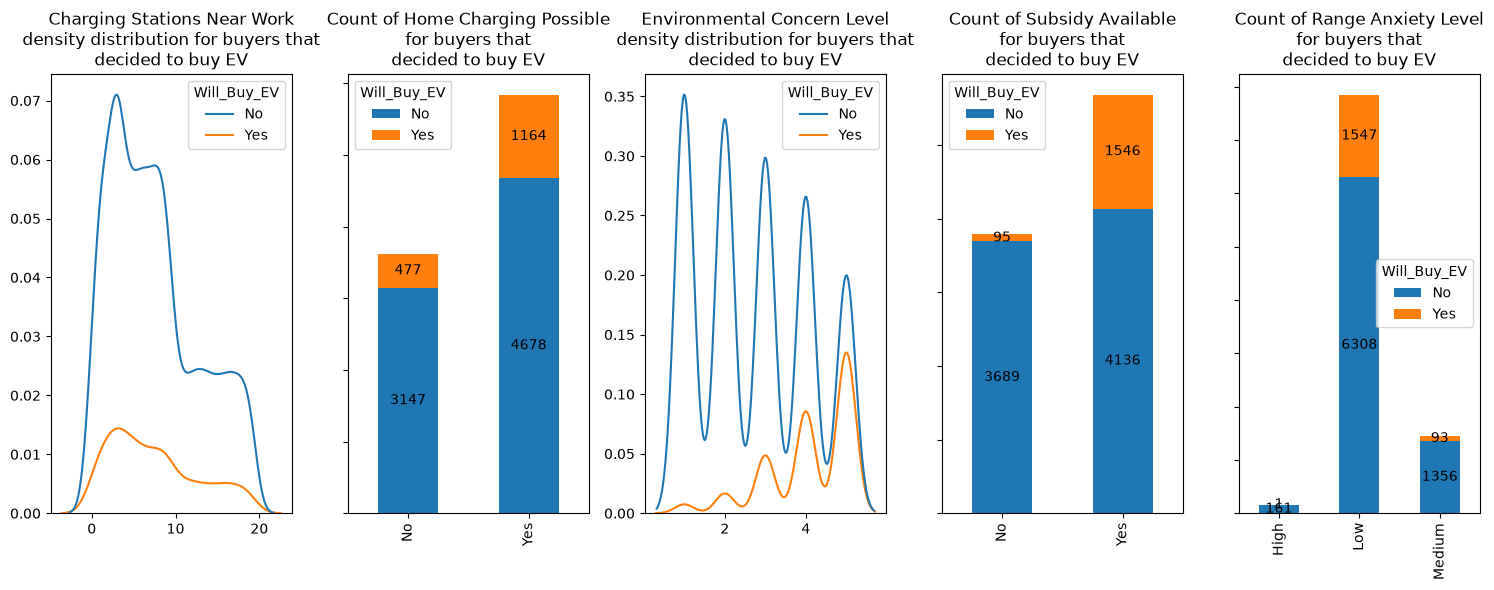

In [10]:
# Detectar automáticamente todas las columnas categóricas
cats = df.select_dtypes(include=['object', 'category']).columns.tolist()

index = 0
    
for _ in [4, 4, 5]:
    fig, axes = plt.subplots(ncols=_, figsize=(15, 6))
    for i in range(_):
        if df.columns[index] in cats:
            df.groupby(df.columns[index])[cats[-1]].value_counts()[:10].unstack().plot(kind="bar", stacked=True, ax=axes[i])
            bar_labels(axes[i], 0, "center")
            axes[i].set_title("Count of {}\nfor buyers that\ndecided to buy EV".format(df.columns[index].replace('_', ' ')))
        else:
            sns.kdeplot(df, x=df.columns[index], hue=df.columns[-1], ax=axes[i])
            axes[i].set_xlabel("")
            axes[i].set_ylabel("")
            axes[i].set_title("{}\ndensity distribution for buyers that\ndecided to buy EV".format(df.columns[index].replace('_', ' ')))
        index += 1
    plt.tight_layout()
    plt.show()

ALGORTIMOS DE CLASIFICACION QUE PREDICEN LA PROBABILIDAD DE QUE UN COMPRADOR ADQUIERA UN VEHICULO ELECTRICO

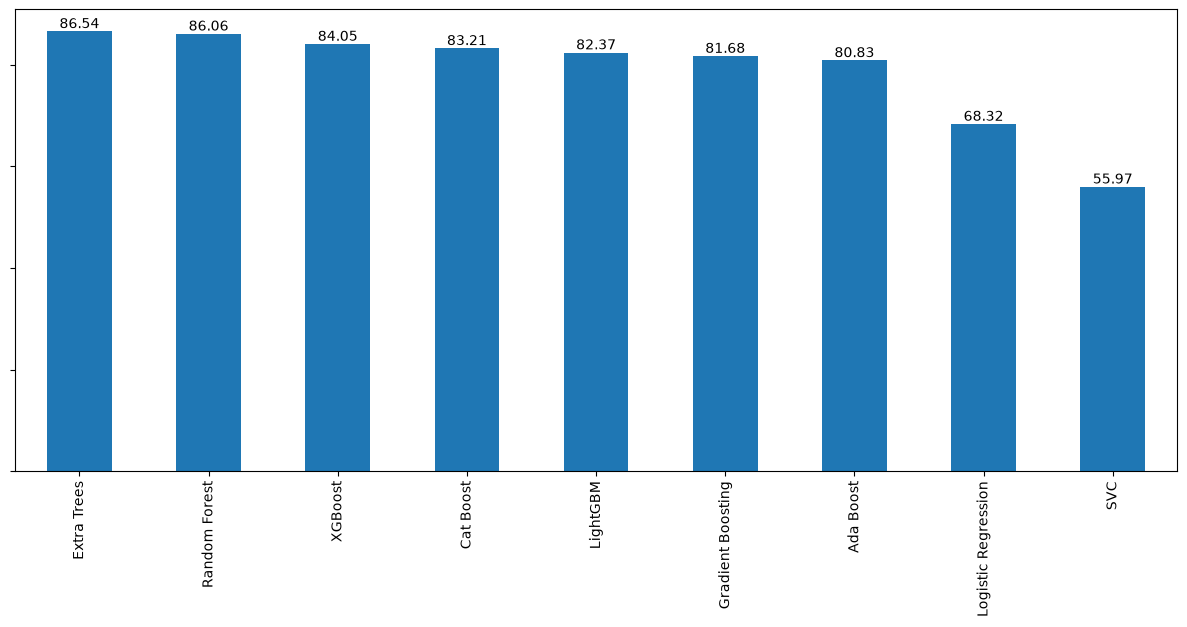

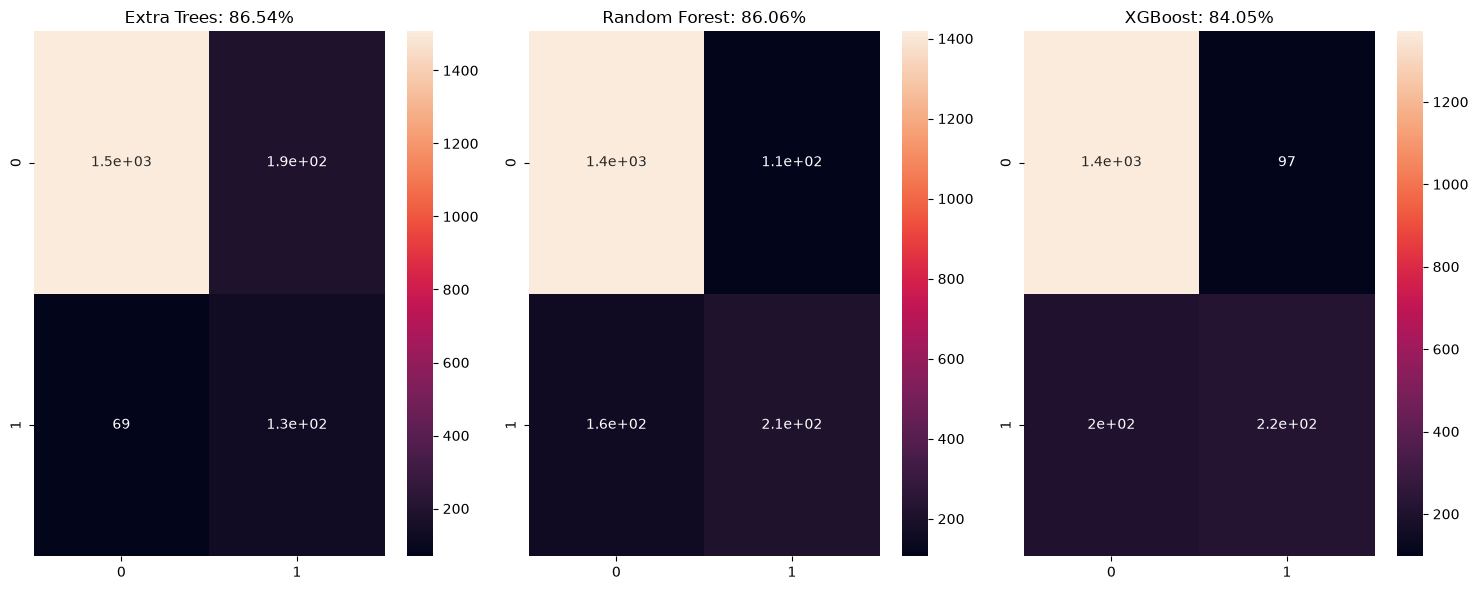

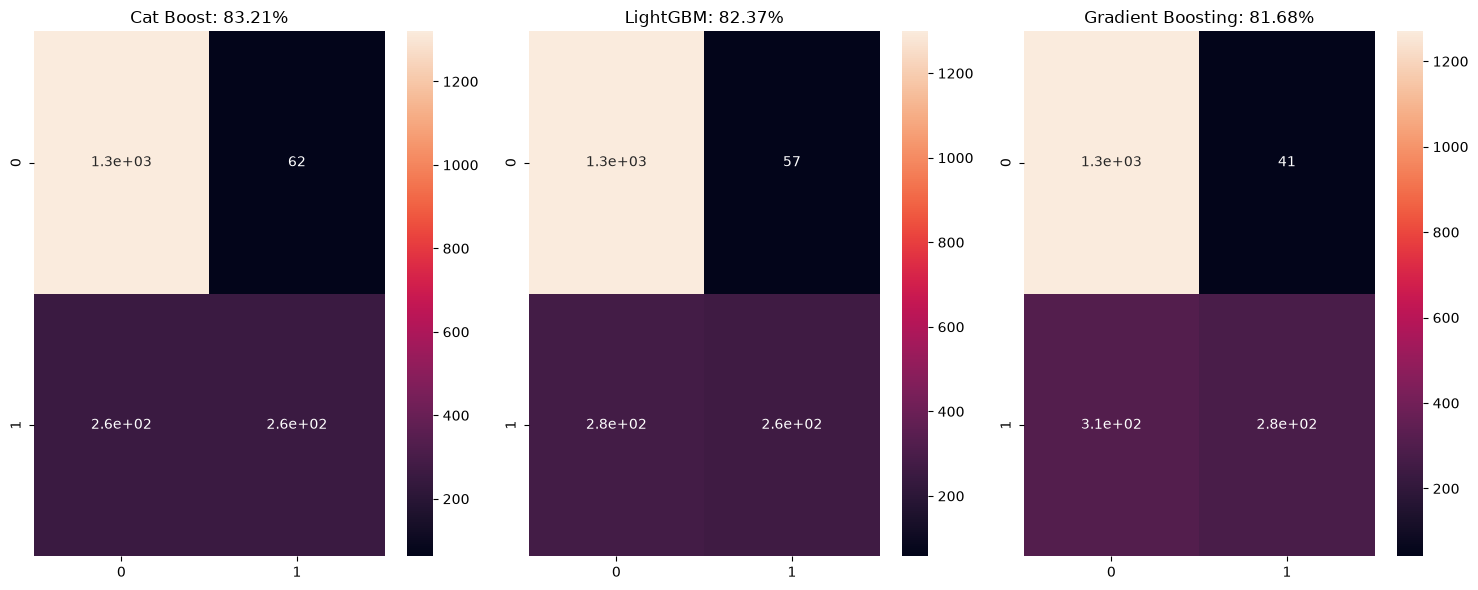

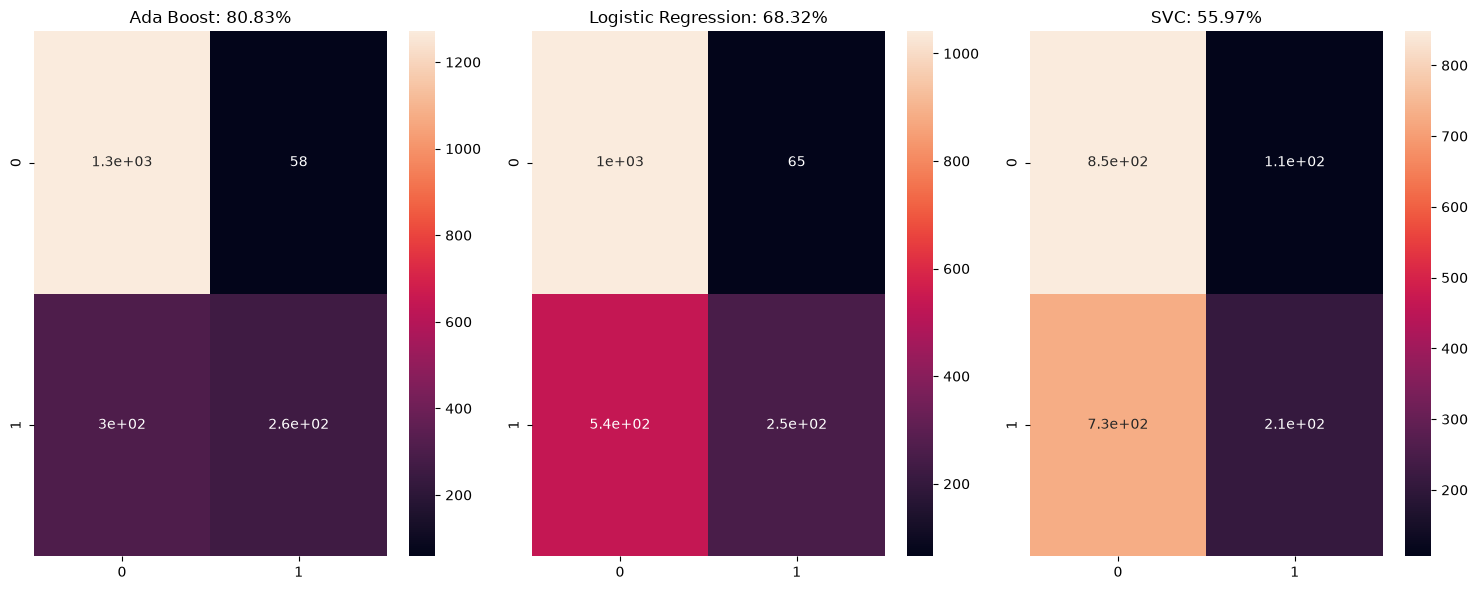

******************************


Extra Trees


              precision    recall  f1-score   support

           0       0.96      0.89      0.92      1693
           1       0.42      0.66      0.51       201

    accuracy                           0.87      1894
   macro avg       0.69      0.77      0.72      1894
weighted avg       0.90      0.87      0.88      1894

******************************


Random Forest


              precision    recall  f1-score   support

           0       0.90      0.93      0.91      1524
           1       0.67      0.57      0.62       370

    accuracy                           0.86      1894
   macro avg       0.78      0.75      0.77      1894
weighted avg       0.85      0.86      0.86      1894

******************************


XGBoost


              precision    recall  f1-score   support

           0       0.87      0.93      0.90      1468
           1       0.69      0.52      0.59       426

    accuracy                           0.84

In [11]:
# 1. Asegurar que 'cats' contenga TODAS las columnas de texto/objeto
cats = df.select_dtypes(include=['object', 'category']).columns

# 2. Codificar todas las columnas de texto en el DataFrame principal
for i in cats:
    enc = LabelEncoder()
    df[i] = enc.fit_transform(df[i].astype(str))

x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# 4. Volver a dividir los datos
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2)

training_classification()